# Tutorial 1: Getting started with Rabbit

In this tutorial you will learn the most basic features, useful scripts, and commands to work with rabbit.

## Setting up the environment

There are many ways to set a working environment. The following is a suggestion that works on my local laptop.

In your terminal, clone the rabbit repository:
``` bash
git clone git@github.com:WMass/rabbit.git
cd rabbit
```

Create a virtual environment (requires python 3.12 or higher):
``` bash
python -m venv env
source env/bin/activate
pip install wums[pickling,plotting] tensorflow tensorflow-probability numpy h5py hist scipy matplotlib mplhep seaborn pandas plotly kaleido
```

Install jupyter notebook specific packages and the kernel spec:
``` bash
pip install ipykernel
python -m ipykernel install --user --name=rabbit_env --display-name "Python (Rabbit)"
```

Start jupyter notebook:
``` bash
jupyter notebook
```

After starting jupyter notebook, open the browser link, and navigate to this file you have to activate the kernel with the environment. Go to "Kernel" -> "Change kernel" -> "Python (Rabbit)".
If everything done right the following command should print the python path inside your python virtual environment:

In [1]:
import sys
print(sys.executable)

/home/david/work/Repos/rabbit/env/bin/python


Since we are using a lot of bash scripts we need to set the environment variables. Outside of a notebook this is done by running `source setup.sh` from the repository root. The cell below replicates the same effect inside the notebook:

In [2]:
import os
import sys
from pathlib import Path

# 1. Emulate RABBIT_BASE (points to the 'rabbit' root)
# Since we are in rabbit/notebooks/, we go up one level
rabbit_base = str(Path(os.getcwd()).parent.absolute())
os.environ['RABBIT_BASE'] = rabbit_base

# 2. Update PYTHONPATH so you can 'import rabbit'
if rabbit_base not in sys.path:
    sys.path.append(rabbit_base)
# 2.1 PYTHONPATH also needs to be set to run bash scripts starting with "!"
pythonpath = os.environ.get('PYTHONPATH', '')
if rabbit_base not in pythonpath:
    os.environ['PYTHONPATH'] = rabbit_base + os.pathsep + pythonpath if pythonpath else rabbit_base
    
# 3. Update PATH so you can run scripts from rabbit/bin/
bin_path = os.path.join(rabbit_base, 'bin')
if bin_path not in os.environ['PATH']:
    os.environ['PATH'] = bin_path + os.pathsep + os.environ['PATH']
    
print(f"RABBIT_BASE: {os.environ['RABBIT_BASE']}")
print(f"PATH: {os.environ['PATH']}")

RABBIT_BASE: /home/david/work/Repos/rabbit
PATH: /home/david/work/Repos/rabbit/env/bin:/home/david/.local/bin:/home/david/.local/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/snap/bin:/home/david/work/Repos/rabbit/bin


The following is needed to visualize the plots within this session

In [3]:
from IPython.display import Image, display, IFrame, HTML

## Generating a synthetic toy model

Let's start creating some toy data, a 1D histogram with 10 bins with a Gaussian signal, a flat background, and an exponentially falling background:

In [4]:
import numpy as np
import hist

axis = hist.axis.Regular(10,0,1, name="x")

# Create histograms for signal, 2 backgrounds, and data 
h_sig = hist.Hist(axis, storage=hist.storage.Weight())  
h_flat = hist.Hist(axis, storage=hist.storage.Weight())  
h_exp = hist.Hist(axis, storage=hist.storage.Weight())  
h_data = hist.Hist(axis, storage=hist.storage.Double())  
  
# Generate and fill components with weights  
np.random.seed(42)  
# Gaussian signal (mean=0.5, std=0.1) with weights  
sig_samples = np.random.normal(0.5, 0.1, 5000)
sig_weights = np.random.normal(1.0, 0.2, 5000)  # Mean weight=1, sigma=0.2 
h_sig.fill(sig_samples, weight=sig_weights)  
  
# Flat background with weights  
flat_samples = np.random.uniform(0, 1, 4000)  
flat_weights = np.random.normal(0.5, 0.1, 4000)  # Mean weight=0.5, sigma=0.1
h_flat.fill(flat_samples, weight=flat_weights)  
  
# Exponential background with weights  
exp_samples = np.random.exponential(0.2, 2000)  
exp_weights = np.random.normal(1.5, 0.3, 2000)  # Mean weight=1.5, sigma=0.3
h_exp.fill(exp_samples, weight=exp_weights)  
  
# Sum components and add Poisson fluctuations
h_data.values()[...] = np.random.poisson(  
    h_sig.values() + h_flat.values() + h_exp.values()  
)

You can visualize any of the histograms e.g.:

In [5]:
print(h_flat)

                  ┌──────────────────────────────────────────────────────────┐
[-inf,   0) 0     │                                                          │
[   0, 0.1) 216.6 │█████████████████████████████████████████████████████████ │
[ 0.1, 0.2) 195.9 │███████████████████████████████████████████████████▌      │
[ 0.2, 0.3) 193.3 │██████████████████████████████████████████████████▉       │
[ 0.3, 0.4) 199.1 │████████████████████████████████████████████████████▍     │
[ 0.4, 0.5) 203.3 │█████████████████████████████████████████████████████▌    │
[ 0.5, 0.6) 211.2 │███████████████████████████████████████████████████████▋  │
[ 0.6, 0.7) 187.4 │█████████████████████████████████████████████████▍        │
[ 0.7, 0.8) 191.7 │██████████████████████████████████████████████████▌       │
[ 0.8, 0.9) 209.9 │███████████████████████████████████████████████████████▎  │
[ 0.9,   1) 201.2 │█████████████████████████████████████████████████████     │
[   1, inf) 0     │                                 

## Constructing the input file rabbit expects

To perform a binned profile maximum likelihood fit of the provided templates to the data histogram we need to construct an input file in the required format. Rabbit offers a python interface to do that. Multiple channels can be provided where each channel has an arbitrary number of axes. Histograms for the data and predictions, called processes, need to be provided in the same axes. In the underlying data structure the multi-dimensional histogram for each channel get unrolled and that flat arrays get concatenated.

In our case we just have one channel and histograms with a single axis. 

In [6]:
from rabbit import tensorwriter  
  
# Initialize TensorWriter  
writer = tensorwriter.TensorWriter(
    systematic_type="log_normal"
)  
  
# Add a channel 
#  each channel can have different axes and can for example represent an analysis region 
#  such as single lepton channel and dilepton channel
writer.add_channel([axis], name="ch0")
  
# Add observed data  
writer.add_data(h_data, "ch0")  
  
# Add processes: signal and backgrounds  
writer.add_process(h_sig, "signal", "ch0", signal=True)  
writer.add_process(h_flat, "flat_bkg", "ch0", signal=False)  
writer.add_process(h_exp, "exp_bkg", "ch0", signal=False)  

A real measurement has systematic uncertainties. Rabbit does not distinguish between normalization and shape uncertainties. Each uncertainty source is characterized by one up and one down variation across all bins, per process. Internally a 4D tensor is constructed with (processes, bins, systematics, up/down) variation. It is possible to symmetrize systematic variations to make the likelihood more quadratic and aid the minimization and establish validity of Gaussian approximations for example for the uncertainty estimation. 
* For systematic variations that are expected to by symmetric (but may have some statistical fluctuations which makes them asymmetric) the option "average" is recommended which is, as the name suggests, building the average of the up and down variation. 
* For ones that are known to be asymmetric, the "linear" or "quadratic" (more conservative) options are recommended where the asymmetric variation is split into two symmetric variations, one for the average and one for the difference.
* If only one histogram is provided it will be assumed as symmetric and mirrored.

If systematic uncertainties are only provided for a subset of the channels or processes the variations get zero padded. 

By default, all systematic uncertainties have a multiplicative effect on the predicted yield and are log-normal constraint. Alternatively additive normal constrained systematics can be used by setting systematic_type to "normal" in the TensorWriter construction.

In [7]:
# Normalization systematics
writer.add_norm_systematic("lumi", ["signal", "flat_bkg", "exp_bkg"], "ch0", 1.01)
writer.add_norm_systematic("flat_bkg_norm", "flat_bkg", "ch0", 1.05)
writer.add_norm_systematic("exp_bkg_norm", "exp_bkg", "ch0", 1.07)

# Shape systematics: create up/down variations  
def make_shape_var(h, factor_func):  
    h_var = h.copy()  
    centers = h.axes[0].centers  
    weights = factor_func(centers)  
    h_var.values()[...] = h.values() * (1 + weights)  
    return h_var  
  
# Example: asymmetric shape systematic for flat systematic  
h_flat_up = make_shape_var(h_flat, lambda c: 0.05 * np.exp(2 * (c - 0.5)))  
h_flat_dn = make_shape_var(h_flat, lambda c: -0.03 * np.exp(2 * (c - 0.5))) 
writer.add_systematic(  
    [h_flat_up, h_flat_dn],  
    "flat_bkg_shape",  
    "flat_bkg",  
    "ch0",  
    symmetrize="linear", # this splits the systematic into two: 'flat_bkg_shapeSymAvg' and 'flat_bkg_shapeSymDiff'
    constrained=True,  
) 
  
# Example: linear slope systematic for signal  
h_sig_up = make_shape_var(h_sig, lambda c: 0.5 * (c - 0.5))  
h_sig_dn = make_shape_var(h_sig, lambda c: -0.5 * (c - 0.5))  
writer.add_systematic(  
    [h_sig_up, h_sig_dn],  
    "slope",  
    "signal",  
    "ch0",  
    symmetrize="average",  
    constrained=False,  
)

/home/david/work/Repos/rabbit/rabbit/tensorwriter.py:459: RuntimeWarning: invalid value encountered in divide
  _logk = kfac * np.log(syst / norm)


Finally, we store the file on disk. Note that a `RuntimeWarning: invalid value encountered in divide` may appear when adding systematics — this is expected and harmless. It occurs when a process has zero nominal yield in some bins, causing `log(0)` during the internal log-normal encoding; those entries are clipped to a small numerical value automatically.

In [8]:
import os

directory="results/getting_started/"
if not os.path.exists(directory):
    os.makedirs(directory)

# Write the input tensor to HDF5  
writer.write(
    outfilename=f"{directory}/input.hdf5"
)

The following steps are using bash commands to investigate

## Input data diagnostics

First, let us look if the input data looks healthy

In [9]:
!debug_inputdata.py results/getting_started/input.hdf5 -v 4

2026-03-15 19:33:32.230214: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 19:33:32.230521: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 19:33:32.265862: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-15 19:33:33.145917: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

Looks good! However, the scripts does not know what you are trying to do and the checks have a limited coverage. It does not guarantee that things work. 
More insight can be obtained from looking at the data, nominal predictions, and systematic variations, exactly as they go into the fit. Do the variations look sane to you?

2026-03-15 19:33:44.185281: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 19:33:44.185589: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 19:33:44.227512: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-15 19:33:45.107593: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

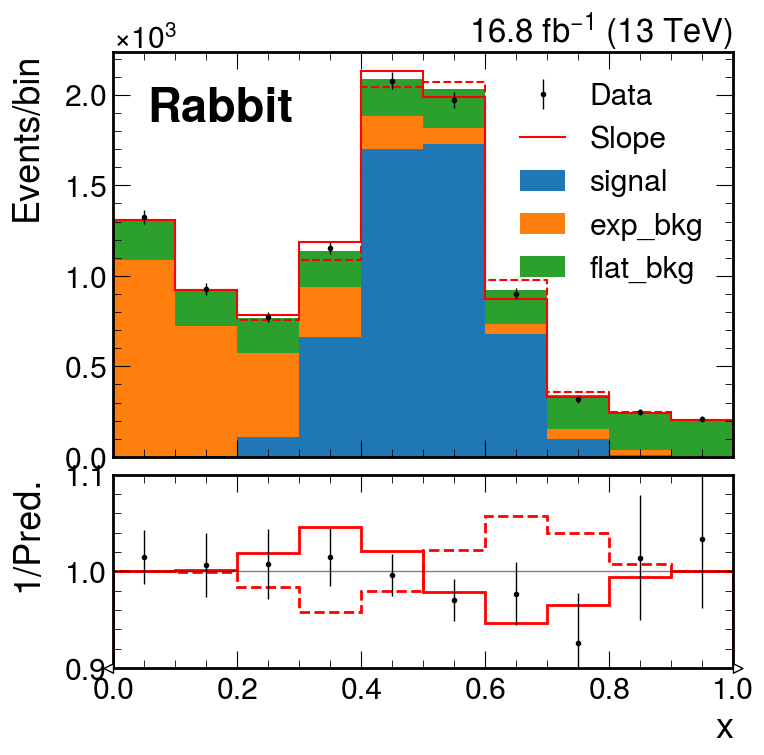

In [10]:
!rabbit_plot_inputdata.py ./results/getting_started/input.hdf5 -o ./results/getting_started --legCols 1 \
--varName slope --varLabel 'Slope' --varColor red

display(Image(filename='results/getting_started/hist_stack_x_ch0.png'))

## Fit

From the provided input data a likelihood function is constructed that has to be maximized. As usual, the negative logarithm of the likelihood is implemented for minimization and constant terms are neglected:

$-\ln\left( \mathcal{L} \right) = \sum_{i=1}^\mathrm{bins} \left[ n^\mathrm{exp}_i - n^\mathrm{obs}_i \ln(n^\mathrm{exp}_i) \right] + \frac{1}{2} \sum_{k=1}^\mathrm{syst} \left(\theta_k - \theta^0_k\right)^2 + \sum_{i=1}^\mathrm{bins} \left[ k^\mathrm{stat}_i \beta_i - k^\mathrm{stat}_i \beta_i^0 \ln(\beta_i) \right]$

with $n_i = \sum_j^\mathrm{proc} f_{i,j}(\vec{\mu}) \beta_i n_{i,j}^0 \prod_k^\mathrm{syst} \kappa_{i,j,k}^{\theta_k}$ and $\kappa_{i, j, k} = \frac{n^0_{i,j} + v_{i, j, k}}{n^0_{i,j}}$. 
With the bin index $i$, process index $j$ and systematic index $k$. The parameters associated to each systematic variation is $\theta$ while $\theta^0$ is the constraint minimum that is by default set to 0 but can be varied for toy experiments. The $\beta$ and $\beta^0$ parameters account for the statistical uncertainty on the prediction and the Barlow--Beeston light approach is followed by default. The $k^\mathrm{stat}$ numbers encodes the statistical uncertainty on the predictions. The $\mu$ are parameters of interest (POI) and their effect on the yields is modelled via the so-called POI model $f$, which by default returns 1 for signal and 0 for background processes. 

The `-t` option selects which dataset to fit:
- `-t -1`: fit to the **Asimov dataset**, where observed data = sum of all prefit predictions. Use this to get expected sensitivities and to validate the fit setup before looking at real data.
- `-t 0`: fit to the **observed data**.
- Multiple values (e.g. `-t 0 -1`) run both fits and store the results under separate keys in the output file.

By default fits to data are **blinded**: a random offset is applied to the POIs so the true data result is not visible until you add `--unblind`.

To start with, we perform a fit to the Asimov dataset using `-t -1` and save:
- the expected prefit and postfit distribution (`--saveHists`) for each process (`--saveHistsPerProcess`) and the total uncertainties (`--computeHistErrors`)
- the effect of the systematic variations (`--computeVariations`)
- the uncertainty breakdown on the signal strength modifier following the traditional (`--doImpacts`) and global impacts definition (`--globalImpacts`)

When the fit terminates it prints out the estimated distance to the minimum (edmval). If the edmval is large (e.g. larger than $10^{-9}$) it is a sign that the fit has not converged. 
It also prints the p-value from the saturated likelihood test in the asymptotic limit. This tells you how well your model describes the data.

In [11]:
!rabbit_fit.py ./results/getting_started/input.hdf5 -t -1 -o ./results/getting_started \
--saveHists --saveHistsPerProcess --computeHistErrors --computeVariations --doImpacts --globalImpacts

2026-03-15 19:33:50.797558: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 19:33:50.797905: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 19:33:50.833069: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-15 19:33:51.771872: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

Various settings can be specified via command line options, see:

In [12]:
!rabbit_fit.py --help

2026-03-15 19:34:03.925662: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 19:34:03.925959: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 19:34:03.961242: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-15 19:34:04.910623: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

## Fit Diagnostics

### Prefit & postfit plots

In [13]:
!rabbit_plot_hists.py results/getting_started/fitresults.hdf5 -m BaseMapping -o ./results/getting_started \
 --legCols 1 --rrange 0.8 1.2 --extraTextLoc 0.05 0.82 \
--varName slope --varLabel 'Slope' --varColor red --prefit

!rabbit_plot_hists.py results/getting_started/fitresults.hdf5 -m BaseMapping -o ./results/getting_started \
--legCols 1 --rrange 0.8 1.2 --extraTextLoc 0.05 0.82 \
--varName slope --varLabel 'Slope' --varColor red

# this is needed to force refreshing HTML if the figures get re-generated
import time
v = time.time()

display(HTML("""
<div style="display: flex; justify-content: space-around;">
    <img src="results/getting_started/prefit_x_ch0_BaseMapping.png?v={v}" style="width: 45%;" />
    <img src="results/getting_started/postfit_x_ch0_BaseMapping.png?v={v}" style="width: 45%;" />
</div>
"""))

INFO:rabbit_plot_hists.py: Make plot for BaseMapping in channel ch0
INFO:plot_tools.py: Wrote file(s) ./results/getting_started//prefit_x_ch0_BaseMapping.pdf(.png)
INFO:plot_tools.py: Wrote file(s) ./results/getting_started//prefit_x_ch0_BaseMapping.pdf(.png)
INFO:rabbit_plot_hists.py: Make plot for BaseMapping in channel ch0
INFO:plot_tools.py: Wrote file(s) ./results/getting_started//postfit_x_ch0_BaseMapping.pdf(.png)
INFO:plot_tools.py: Wrote file(s) ./results/getting_started//postfit_x_ch0_BaseMapping.pdf(.png)


### Pulls and impacts

Impact parameter pulls and impacts are computed by default on all parameters of interest and in the Gaussian approximation. Here, the impact on the signal strength modifier is plotted.

In [14]:
!rabbit_plot_pulls_and_impacts.py results/getting_started/fitresults.hdf5 -o ./results/getting_started

IFrame(src='results/getting_started/pulls_and_impacts_signal.html', width='100%', height=300)

Now at signal
Write output file ./results/getting_started/pulls_and_impacts_signal.html
Write output file ./results/getting_started/impacts_grouped_signal.html


### Correlation matrix
Let's look at the correlation of some parameters

INFO:plot_tools.py: Wrote file(s) ./results/getting_started//hist_corr_postfit_parms_x_parms_y_params.pdf(.png)
INFO:plot_tools.py: Wrote file(s) ./results/getting_started//hist_corr_postfit_parms_x_parms_y_params.pdf(.png)


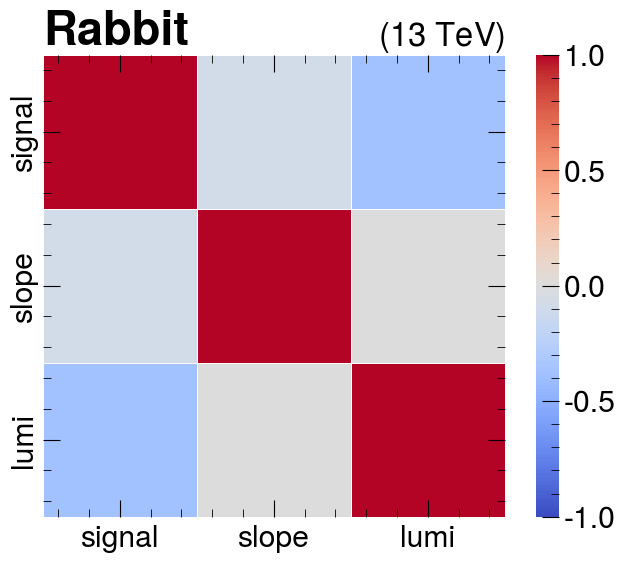

In [15]:
!rabbit_plot_hists_cov.py results/getting_started/fitresults.hdf5 \
--params signal slope lumi --correlation -o ./results/getting_started --titlePos 0

display(Image(filename='results/getting_started/hist_corr_postfit_parms_x_parms_y_params.png'))

### Likelihood scans

Let's perform another fit, this time on data and asimov (-t 0 -1). And also perform a likelihood scan of the signal strength modifier.

We also enable debug to see what is going on. 
The message "A bad approximation caused failure to predict improvement" is expected, what counts is the estimated distance to minimum (edmval), if this is low we are reassured to have found a good minimum.

In [16]:
!rabbit_fit.py results/getting_started/input.hdf5 -t 0 -1 -o ./results/getting_started \
--scan signal --postfix nll_scan -v 4

2026-03-15 19:34:37.683667: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 19:34:37.683988: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 19:34:37.718839: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-15 19:34:38.658897: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

DEBUG:fitter.py: Iteration 87: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 88: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 89: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 90: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 91: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 92: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 93: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 94: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 95: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 96: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 97: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 98: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 99: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 100: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 101: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 102: loss value 0.45506785046489384
DEBUG

DEBUG:fitter.py: Iteration 207: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 208: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 209: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 210: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 211: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 212: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 213: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 214: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 215: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 216: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 217: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 218: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 219: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 220: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 221: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 222: loss value 0.4550678504

DEBUG:fitter.py: Iteration 334: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 335: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 336: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 337: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 338: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 339: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 340: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 341: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 342: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 343: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 344: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 345: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 346: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 347: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 348: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 349: loss value 0.4550678504

DEBUG:fitter.py: Iteration 465: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 466: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 467: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 468: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 469: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 470: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 471: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 472: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 473: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 474: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 475: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 476: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 477: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 478: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 479: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 480: loss value 0.4550678504

...

DEBUG:fitter.py: Iteration 1117: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1118: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1119: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1120: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1121: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1122: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1123: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1124: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1125: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1126: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1127: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1128: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1129: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1130: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1131: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1132: loss va

DEBUG:fitter.py: Iteration 1229: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1230: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1231: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1232: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1233: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1234: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1235: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1236: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1237: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1238: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1239: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1240: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1241: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1242: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1243: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1244: loss va

DEBUG:fitter.py: Iteration 1359: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1360: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1361: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1362: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1363: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1364: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1365: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1366: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1367: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1368: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1369: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1370: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1371: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1372: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1373: loss value 0.45506785046489384
DEBUG:fitter.py: Iteration 1374: loss va

DEBUG:fitter.py: Iteration 1: loss value 5.041379775311718
DEBUG:fitter.py: Iteration 2: loss value 5.041371941763174
DEBUG:fitter.py: Iteration 3: loss value 5.041371941745063
DEBUG:fitter.py: Iteration 4: loss value 5.041371941745063
DEBUG:fitter.py:  message: A bad approximation caused failure to predict improvement.
 success: False
  status: 2
     fun: 5.041371941745063
       x: [ 1.716e+02 -4.084e-01  2.873e-01  4.698e-01  1.735e-01
            4.860e-02  1.116e+00]
     nit: 5
     jac: [ 0.000e+00 -9.766e-14 -8.177e-14  3.378e-12  5.247e-12
           -3.344e-11 -6.541e-13]
    nfev: 7
    njev: 7
    nhev: 21
DEBUG:fitter.py: Now at i=1 x=179.74799670607447
DEBUG:fitter.py: Iteration 0: loss value 0.547138832415329
DEBUG:fitter.py: Iteration 1: loss value 0.5466487685616518
DEBUG:fitter.py: Iteration 2: loss value 0.5466486373027741
DEBUG:fitter.py: Iteration 3: loss value 0.5466486373027741
DEBUG:fitter.py:  message: A bad approximation caused failure to predict improvement.

DEBUG:fitter.py: Iteration 4: loss value 1.485840521337026
DEBUG:fitter.py:  message: A bad approximation caused failure to predict improvement.
 success: False
  status: 2
     fun: 1.485840521337026
       x: [ 9.775e-01  7.545e-02  9.862e-02  2.540e-01  4.625e-02
            1.847e-02  6.457e-01]
     nit: 5
     jac: [ 0.000e+00 -3.061e-14  2.541e-14  4.814e-13  1.258e-12
           -7.111e-12 -4.163e-14]
    nfev: 7
    njev: 7
    nhev: 21
DEBUG:fitter.py: Now at i=5 x=0.9718694419656353
DEBUG:fitter.py: Iteration 0: loss value 2.336887135953985
DEBUG:fitter.py: Iteration 1: loss value 2.327990858616556
DEBUG:fitter.py: Iteration 2: loss value 2.3279861202860452
DEBUG:fitter.py: Iteration 3: loss value 2.3279861202632777
DEBUG:fitter.py: Iteration 4: loss value 2.3279861202632777
DEBUG:fitter.py:  message: A bad approximation caused failure to predict improvement.
 success: False
  status: 2
     fun: 2.3279861202632777
       x: [ 9.719e-01  9.550e-02  1.241e-01  3.205e-01  5.80

In [17]:
!rabbit_plot_likelihood_scan.py results/getting_started/fitresults_nll_scan.hdf5 \
--param signal --postfix data -o ./results/getting_started/

!rabbit_plot_likelihood_scan.py results/getting_started/fitresults_nll_scan.hdf5 \
--param signal --postfix asimov --result asimov -o ./results/getting_started/

# this is needed to force refreshing HTML if the figures get re-generated
import time
v = time.time()

display(HTML("""
<div style="display: flex; justify-content: space-around;">
    <img src="results/getting_started/nll_scan_signal_asimov.png?v={v}" style="width: 45%;" />
    <img src="results/getting_started/nll_scan_signal_data.png?v={v}" style="width: 45%;" />
</div>
"""))

INFO:plot_tools.py: Wrote file(s) ./results/getting_started//nll_scan_signal_data.pdf(.png)
INFO:plot_tools.py: Wrote file(s) ./results/getting_started//nll_scan_signal_data.pdf(.png)
INFO:plot_tools.py: Wrote file(s) ./results/getting_started//nll_scan_signal_asimov.pdf(.png)
INFO:plot_tools.py: Wrote file(s) ./results/getting_started//nll_scan_signal_asimov.pdf(.png)


Both scans agree very well from the Gaussian approximation from the Hesse matrix.
The "signal" value is shifted by a large amount in the fit to data, this is because by default a blinding offset is applied to parameters of interest. Let's remove it.

In [18]:
!rabbit_fit.py results/getting_started/input.hdf5 -t 0 -1 -o ./results/getting_started \
--scan signal --postfix nll_scan_unblinded -v 4 --unblind

2026-03-15 19:35:01.197759: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 19:35:01.198078: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 19:35:01.235052: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-15 19:35:02.199344: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

DEBUG:fitter.py:  message: A bad approximation caused failure to predict improvement.
 success: False
  status: 2
     fun: 0.5466486340494675
       x: [ 9.960e-01 -5.324e-01  8.721e-02 -5.377e-02  8.201e-02
            1.123e-02 -1.616e-01]
     nit: 4
     jac: [ 0.000e+00  1.277e-09  2.269e-09  1.744e-09  3.076e-09
            5.524e-10  1.020e-09]
    nfev: 6
    njev: 6
    nhev: 18
DEBUG:fitter.py: Now at i=2 x=1.001655162143637
DEBUG:fitter.py: Iteration 0: loss value 0.8208344694163234
DEBUG:fitter.py: Iteration 1: loss value 0.8203638029764313
DEBUG:fitter.py: Iteration 2: loss value 0.8203637250864895
DEBUG:fitter.py: Iteration 3: loss value 0.8203637250864895
DEBUG:fitter.py:  message: A bad approximation caused failure to predict improvement.
 success: False
  status: 2
     fun: 0.8203637250864895
       x: [ 1.002e+00 -5.463e-01  6.360e-02 -1.138e-01  7.101e-02
            6.839e-03 -3.236e-01]
     nit: 4
     jac: [ 0.000e+00  7.005e-10  1.504e-09  1.026e-09  1.816e-09

DEBUG:fitter.py: Iteration 3: loss value 2.3279861202632777
DEBUG:fitter.py: Iteration 4: loss value 2.3279861202632777
DEBUG:fitter.py:  message: A bad approximation caused failure to predict improvement.
 success: False
  status: 2
     fun: 2.3279861202632777
       x: [ 9.719e-01  9.550e-02  1.241e-01  3.205e-01  5.804e-02
            2.325e-02  8.057e-01]
     nit: 5
     jac: [ 0.000e+00 -6.613e-14  9.401e-14  1.017e-12  2.380e-12
           -1.350e-11 -1.105e-13]
    nfev: 7
    njev: 7
    nhev: 21
DEBUG:fitter.py: Now at i=6 x=0.9662433303587623
DEBUG:fitter.py: Iteration 0: loss value 3.3702965452500733
DEBUG:fitter.py: Iteration 1: loss value 3.361421317666846
DEBUG:fitter.py: Iteration 2: loss value 3.3614148668610735
DEBUG:fitter.py: Iteration 3: loss value 3.3614148668352395
DEBUG:fitter.py: Iteration 4: loss value 3.3614148668352395
DEBUG:fitter.py:  message: A bad approximation caused failure to predict improvement.
 success: False
  status: 2
     fun: 3.36141486683523

In [19]:
!rabbit_print_pulls_and_constraints.py results/getting_started/fitresults_nll_scan_unblinded.hdf5

   Parameter                        pull +/- constraint (pull prefit +/- constraint prefit)
   ----------------------------------------------------------------------------------------------------
   signal                         0.99043 +/-    0.01309 (        1.0 +/-               0.0)
   slope                          -0.51826 +/-    0.53436 (        0.0 +/-               0.0)
   exp_bkg_norm                   0.11113 +/-    0.49335 (        0.0 +/-               1.0)
   flat_bkg_norm                  0.00738 +/-     0.8977 (        0.0 +/-               1.0)
   flat_bkg_shapeSymAvg           0.09311 +/-     0.6746 (        0.0 +/-               1.0)
   flat_bkg_shapeSymDiff          0.01567 +/-    0.98815 (        0.0 +/-               1.0)
   lumi                             -0.0 +/-        1.0 (        0.0 +/-               1.0)


How to read the pulls table:
- **pull**: the postfit parameter value. For constrained nuisances this is in units of the prefit uncertainty (a pull of 0 means the nuisance is at its prefit central value, ±1 means it shifted by one standard deviation). For unconstrained parameters (POIs and free parameters like `slope`) it is the fitted value in its natural units.
- **constraint**: the postfit uncertainty, again in units of the prefit uncertainty for constrained nuisances. A value significantly less than 1 indicates the data is constraining that nuisance beyond the prior.
- The values in parentheses are the **prefit** equivalents: the prior central value and uncertainty before the fit.

In [20]:
!rabbit_plot_likelihood_scan.py results/getting_started/fitresults_nll_scan_unblinded.hdf5 \
--param signal --postfix data_unblinded -o ./results/getting_started

# this is needed to force refreshing HTML if the figures get re-generated
import time
v = time.time()

display(HTML("""
<div style="display: flex; justify-content: space-around;">
    <img src="results/getting_started/nll_scan_signal_asimov.png?v={v}" style="width: 45%;" />
    <img src="results/getting_started/nll_scan_signal_data_unblinded.png?v={v}" style="width: 45%;" />
</div>
"""))

INFO:plot_tools.py: Wrote file(s) ./results/getting_started//nll_scan_signal_data_unblinded.pdf(.png)
INFO:plot_tools.py: Wrote file(s) ./results/getting_started//nll_scan_signal_data_unblinded.pdf(.png)


## Summary

In this tutorial you have learned how to:
- Build an input tensor with `TensorWriter`: channels, processes, normalization and shape systematics
- Diagnose input data with `debug_inputdata.py` and `rabbit_plot_inputdata.py`
- Run a profile likelihood fit with `rabbit_fit.py` on Asimov (`-t -1`) and observed data (`-t 0`)
- Interpret fit results: prefit/postfit distributions, pulls and constraints, impacts, correlation matrix, and likelihood scans
- Use blinding and unblinding to protect the data result during fit development

**Next steps:** [Tutorial 2](tutorial_2_advanced.ipynb) covers multi-dimensional channels, masked channels for cross section measurements, custom mappings, and custom POI models.